findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

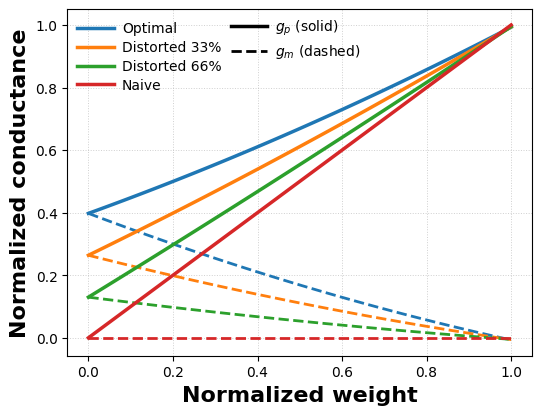

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc
from matplotlib.ticker import MultipleLocator

# --- Parameters ---
g_min, g_max = 0.1, 25.0
g_range = g_max - g_min
w = np.linspace(0.0, 1.0, 100)  # normalized weight vector

# --- 1) Optimal mapping (given polynomials) ---
gp_opt = 2.64268112*w**2 + 12.1806845*w + 10.00479516
gm_opt = 2.64268112*w**2 - 12.7193155*w + 10.00479516

# --- Distortion base (GM polynomial) ---
gm_poly = 2.64268112*w**2 - 12.7193155*w + 10.00479516

# --- 2) 33% distortion ---
gm_33 = (1.0 - 1.0/3.0) * gm_poly
gp_33 = w * g_range + gm_33

# --- 3) 66% distortion ---
gm_66 = (1.0 - 2.0/3.0) * gm_poly
gp_66 = w * g_range + gm_66

# --- 4) Naive mapping ---
gp_naive = g_min + w * g_range
gm_naive = np.full_like(w, g_min)

# --- Normalize conductances to [0, 1] ---
def g_norm(g):
    return (g - g_min) / g_range

gp_opt_n, gm_opt_n   = g_norm(gp_opt),   g_norm(gm_opt)
gp_33_n,  gm_33_n    = g_norm(gp_33),    g_norm(gm_33)
gp_66_n,  gm_66_n    = g_norm(gp_66),    g_norm(gm_66)
gp_naive_n, gm_naive_n = g_norm(gp_naive), g_norm(gm_naive)

# --- Plot ---
rc('font',**{'family':'sans-serif','sans-serif':['Arial']})
plt.rcParams['font.family'] = 'Arial'
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.grid(True, which='both', axis='both', linestyle=':', linewidth=0.7, alpha=0.6)

# Colors per strategy
colors = ['C0', 'C1', 'C2', 'C3']
labels = ['Optimal', 'Distorted 33%', 'Distorted 66%', 'Naive']

# Draw lines (solid = gp, dashed = gm), each with unique label
ax.plot(w, gp_opt_n,   color=colors[0], lw=2.5, ls='-',  label='Optimal $g_p$')
ax.plot(w, gm_opt_n,   color=colors[0], lw=2.0, ls='--', label='Optimal $g_m$')

ax.plot(w, gp_33_n,    color=colors[1], lw=2.5, ls='-',  label='33% Distorted $g_p$')
ax.plot(w, gm_33_n,    color=colors[1], lw=2.0, ls='--', label='33% Distorted $g_m$')

ax.plot(w, gp_66_n,    color=colors[2], lw=2.5, ls='-',  label='66% Distorted $g_p$')
ax.plot(w, gm_66_n,    color=colors[2], lw=2.0, ls='--', label='66% Distorted $g_m$')

ax.plot(w, gp_naive_n, color=colors[3], lw=2.5, ls='-',  label='Naive $g_p$')
ax.plot(w, gm_naive_n, color=colors[3], lw=2.0, ls='--', label='Naive $g_m$')

from matplotlib.lines import Line2D

# --- proxies (unchanged) ---
color_handles = [
    Line2D([0],[0], color='C0', lw=2.5, ls='-',  label='Optimal'),
    Line2D([0],[0], color='C1', lw=2.5, ls='-',  label='Distorted 33%'),
    Line2D([0],[0], color='C2', lw=2.5, ls='-',  label='Distorted 66%'),
    Line2D([0],[0], color='C3', lw=2.5, ls='-',  label='Naive'),
]
style_handles = [
    Line2D([0],[0], color='k',  lw=2.5, ls='-',  label=r'$g_p$ (solid)'),
    Line2D([0],[0], color='k',  lw=2.0, ls='--', label=r'$g_m$ (dashed)'),
]

# --- move legends to the TOP inside the axes and separate columns ---
# Use 'upper right' so bbox_to_anchor's y refers to the TOP edge
leg_colors = ax.legend(
    handles=color_handles,
    loc='upper left',
    bbox_to_anchor=(0.01, 0.98),   # <--- move LEFT/RIGHT with x, UP/DOWN with y (axes coords)
    frameon=False,
    fontsize=10,
    ncol=1,
    borderaxespad=0.0,
    handlelength=2.6,
    handletextpad=0.6,
    labelspacing=0.35
)

leg_styles = ax.legend(
    handles=style_handles,
    loc='upper left',
    bbox_to_anchor=(0.34, 0.99),   # <--- keep the style legend further RIGHT to avoid overlap
    frameon=False,
    fontsize=10,
    ncol=1,
    borderaxespad=0.0,
    handlelength=2.6,
    handletextpad=0.6,
    labelspacing=0.35
)

# Keep both legends
ax.add_artist(leg_colors)

ax.set_xlabel('Normalized weight', fontsize=16, fontweight='bold')
ax.set_ylabel('Normalized conductance', fontsize=16, fontweight='bold')

plt.savefig("various_mapping.png", dpi=300, bbox_inches='tight')